In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/stud.csv")

In [3]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [4]:
X = df.drop(columns=["math_score"])

In [5]:
X.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88


In [6]:
y = df["math_score"]

In [7]:
num_feature = X.select_dtypes(exclude="object").columns
cat_feature = X.select_dtypes(include="object").columns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [

    ("One Hot Encoding", oh_transformer, cat_feature),
    ("Standard Scaling", numeric_transformer, num_feature)
    ]
)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
X_train = preprocessor.fit_transform(X_train)

In [10]:
X_test = preprocessor.transform(X_test)

In [11]:
X_train

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.03079054,  0.43405338],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.9302895 ,  0.96470125],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.34544287,  1.1636942 ],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
        -0.52274728, -1.02522827],
       [ 0.        ,  1.        ,  0.        , ...,  0.        ,
        -1.49143847, -1.02522827],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.48382733,  1.36268716]], shape=(800, 19))

In [12]:
X_train.shape

(800, 19)

In [76]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def model_evaluation(y_test, y_pred ):

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = mse ** 0.5

    print(f"Mean Squared Error: {mse}")
    print(f"Mean Absolute Error: {mae}")
    print(f"R-squared: {r2}")
    print(f"Root Mean Squared Error: {rmse}")

    return mae, r2, rmse

In [14]:
from sklearn.linear_model import LinearRegression


In [15]:
lr = LinearRegression()

In [16]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
lr.intercept_

np.float64(65.90596978153536)

In [18]:
lr.coef_

array([-6.53244193,  6.53244193, -0.80262367, -0.44330087, -1.42824083,
       -1.41585991,  4.09002528, -0.09454143, -0.81144256,  0.83477083,
       -1.49503027,  0.90431471,  0.66192873, -1.75503744,  1.75503744,
       -1.64482118,  1.64482118,  3.41111378, 10.91718966])

In [19]:
lr_pred = lr.predict(X_test)

In [20]:
model_evaluation(y_test, lr_pred)

Mean Squared Error: 29.095169866715526
Mean Absolute Error: 4.214763142474852
R-squared: 0.8804332983749563
Root Mean Squared Error: 5.393993869732847


In [21]:
lr_train_pred = lr.predict(X_train)


In [22]:
model_evaluation(y_train, lr_train_pred)

Mean Squared Error: 28.33487038064859
Mean Absolute Error: 4.26671184607196
R-squared: 0.8743172040139593
Root Mean Squared Error: 5.323050852720514


<Axes: xlabel='math_score'>

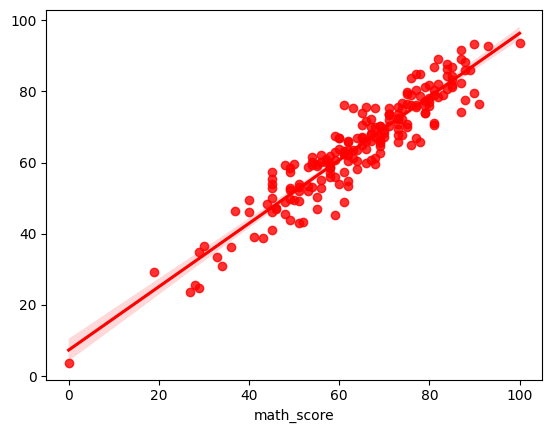

In [23]:
sns.regplot(x = y_test, y = lr_pred, color = "red")

In [24]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42, max_depth=5)


In [25]:
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [26]:
dt_pred = dt.predict(X_test)

In [27]:
dt_train_pred = dt.predict(X_train)

In [28]:
model_evaluation(y_train, dt_train_pred)

Mean Squared Error: 32.687389490741026
Mean Absolute Error: 4.639612351415198
R-squared: 0.8550110711822139
Root Mean Squared Error: 5.71728864854146


In [29]:
model_evaluation(y_test, dt_pred)

Mean Squared Error: 42.77161032657878
Mean Absolute Error: 4.931523210662771
R-squared: 0.8242299188020519
Root Mean Squared Error: 6.540000789493743


In [30]:
from sklearn.ensemble import RandomForestRegressor

In [31]:
rf = RandomForestRegressor(random_state=42, n_estimators=100, max_depth=5)  

In [32]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
rf_pred = rf.predict(X_test)

In [35]:
rf_train_pred = rf.predict(X_train)

In [36]:
model_evaluation(y_train, rf_train_pred)

Mean Squared Error: 28.257943940735863
Mean Absolute Error: 4.2849526604612524
R-squared: 0.8746584206817472
Root Mean Squared Error: 5.3158201569217765


In [34]:
model_evaluation(y_test, rf_pred)

Mean Squared Error: 34.950169604385536
Mean Absolute Error: 4.577075489807686
R-squared: 0.8563721566165244
Root Mean Squared Error: 5.911866845962072


In [37]:
from xgboost import XGBRegressor

In [62]:
xg = XGBRegressor(random_state=42, n_estimators=100, max_depth=5, learning_rate=0.1)

In [63]:
xg.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [64]:
xg_pred = xg.predict(X_test)

In [65]:
xg_train_pred = xg.predict(X_train)

In [66]:
model_evaluation(y_train, xg_train_pred)

Mean Squared Error: 12.119670867919922
Mean Absolute Error: 2.7287187576293945
R-squared: 0.9462417364120483
Root Mean Squared Error: 3.481331766425016


In [67]:
model_evaluation(y_test, xg_pred)

Mean Squared Error: 32.23475646972656
Mean Absolute Error: 4.394774913787842
R-squared: 0.8675311803817749
Root Mean Squared Error: 5.677566069164371


In [70]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

In [69]:
models = {
    "Linear Regression": LinearRegression(),
    "ridge": Ridge(),
    "Lasso": Lasso(),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=42),
    "RandomForestRegressor": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, n_estimators=100)
}

In [71]:
params = {
    "linear Regression": {},
    "ridge": {
        "alpha": [0.01, 0.1,1.0,10.0,50.0]
              },
    "Lasso": {
        "alpha": [0.01, 0.1,1.0,10.0]
    },
    "DecisionTreeRegressor": {
        "max_depth": [3, 5, 7, 10],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    "RandomForestRegressor": {
        "n_estimators": [50, 100, 200],
        "max_depth": [3, 5, 7, 10],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    "XGBoost": {
        "n_estimators": [50, 100, 200],
        "max_depth": [3, 5, 7, 10],
        "learning_rate": [0.01, 0.1, 0.2]
    }
}

In [80]:
# Reset the lists right here so duplicates NEVER happen:
model_list = []
r2_list = []
rmse_list = []
mae_list = []
best_params_list = []

for model_name, model in models.items():
    param_grid = params.get(model_name, {})

    gs = GridSearchCV(model, param_grid, cv=5, scoring='r2', n_jobs=-1)
    gs.fit(X_train, y_train)

    best_model = gs.best_estimator_
    y_test_pred = best_model.predict(X_test)

    # MATCH Cell 12 return order: mae, r2, rmse
    mae, r2, rmse = model_evaluation(y_test, y_test_pred)

    model_list.append(model_name)
    r2_list.append(r2)
    rmse_list.append(rmse)
    mae_list.append(mae)
    best_params_list.append(gs.best_params_)

# OUTSIDE the loop (unindented):
comparison_df = pd.DataFrame({
    "Model": model_list,
    "R2 Score": r2_list,
    "RMSE": rmse_list,  
    "MAE": mae_list,
    "Best Parameters": best_params_list
}).sort_values(by="R2 Score", ascending=False).reset_index(drop=True)
    


    
    

Mean Squared Error: 29.095169866715526
Mean Absolute Error: 4.214763142474852
R-squared: 0.8804332983749563
Root Mean Squared Error: 5.393993869732847
Mean Squared Error: 29.05660162669484
Mean Absolute Error: 4.211112826071165
R-squared: 0.8805917946912825
Root Mean Squared Error: 5.390417574427313
Mean Squared Error: 28.98447131356699
Mean Absolute Error: 4.204586505968742
R-squared: 0.8808882144636153
Root Mean Squared Error: 5.383722811732323
Mean Squared Error: 42.80720060435656
Mean Absolute Error: 4.933606543996104
R-squared: 0.8240836604319065
Root Mean Squared Error: 6.542721192619823
Mean Squared Error: 34.54226898620763
Mean Absolute Error: 4.539551756480152
R-squared: 0.8580484256237091
Root Mean Squared Error: 5.877267135855544
Mean Squared Error: 32.0484619140625
Mean Absolute Error: 4.373194694519043
R-squared: 0.86829674243927
Root Mean Squared Error: 5.661136097468643


In [81]:
comparison_df

,Model,R2 Score,RMSE,MAE,Best Parameters
0,Lasso,0.880888,5.383723,4.204587,{'alpha': 0.01}
1,ridge,0.880592,5.390418,4.211113,{'alpha': 1.0}
2,Linear Regression,0.880433,5.393994,4.214763,{}
3,XGBoost,0.868297,5.661136,4.373195,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
4,RandomForestRegressor,0.858048,5.877267,4.539552,"{'max_depth': 7, 'min_samples_leaf': 2, 'min_s..."
5,DecisionTreeRegressor,0.824084,6.542721,4.933607,"{'max_depth': 5, 'min_samples_leaf': 4, 'min_s..."


In [82]:
from sklearn.linear_model import Lasso

# Train the best Lasso model (alpha=0.01 was selected by GridSearchCV)
best_lasso = Lasso(alpha=0.01)
best_lasso.fit(X_train, y_train)

# Predict on both sets
y_train_pred = best_lasso.predict(X_train)
y_test_pred = best_lasso.predict(X_test)

# Evaluate both
mae_train, r2_train, rmse_train = model_evaluation(y_train, y_train_pred)
mae_test, r2_test, rmse_test = model_evaluation(y_test, y_test_pred)

print(f"--- GENERALIZATION CHECK ---")
print(f"Train R2: {r2_train:.4f} | Train RMSE: {rmse_train:.4f}")
print(f"Test R2:  {r2_test:.4f} | Test RMSE:  {rmse_test:.4f}")

Mean Squared Error: 28.344706319643514
Mean Absolute Error: 4.266423776642394
R-squared: 0.8742735754990791
Root Mean Squared Error: 5.323974673084341
Mean Squared Error: 28.98447131356699
Mean Absolute Error: 4.204586505968742
R-squared: 0.8808882144636153
Root Mean Squared Error: 5.383722811732323
--- GENERALIZATION CHECK ---
Train R2: 0.8743 | Train RMSE: 5.3240
Test R2:  0.8809 | Test RMSE:  5.3837


In [83]:
# Check the mean cross-validation score during GridSearchCV:
# In your loop, gs.best_score_ stores the average 5-fold CV R2 score on training data:
print("Cross-Validation R2 Score (5-fold):", gs.best_score_)

Cross-Validation R2 Score (5-fold): 0.8487370848655701


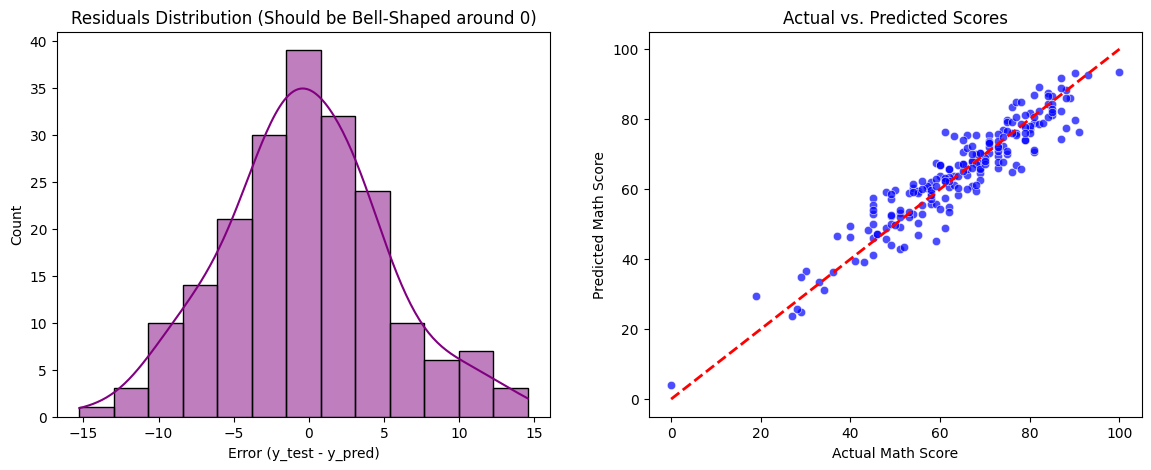

In [84]:
residuals = y_test - y_test_pred

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Residuals histogram
sns.histplot(residuals, kde=True, ax=ax[0], color="purple")
ax[0].set_title("Residuals Distribution (Should be Bell-Shaped around 0)")
ax[0].set_xlabel("Error (y_test - y_pred)")

# 2. Actual vs Predicted scatter plot
sns.scatterplot(x=y_test, y=y_test_pred, ax=ax[1], color="blue", alpha=0.7)
ax[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
ax[1].set_title("Actual vs. Predicted Scores")
ax[1].set_xlabel("Actual Math Score")
ax[1].set_ylabel("Predicted Math Score")

plt.show()

In [86]:
best_model

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
